<a href="https://colab.research.google.com/github/springboardmentor14065l/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/Nikhil-yadav/week%203-4/Baseline_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/final_feature_table.csv")


In [4]:
target = 'Energy Consumption (kWh)'

X = df.drop(columns=[target])
y = df[target]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [6]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)


LinearRegression()

In [7]:
y_pred = baseline_model.predict(X_test)


In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Baseline Linear Regression MAE  : {mae:.4f}")
print(f"Baseline Linear Regression RMSE : {rmse:.4f}")


Baseline Linear Regression MAE  : 0.0000
Baseline Linear Regression RMSE : 0.0000


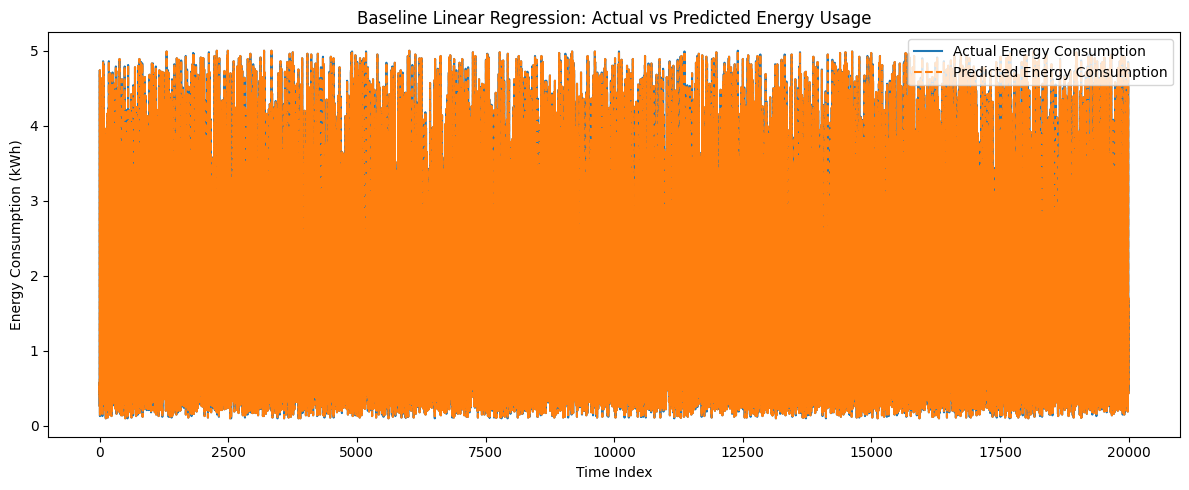

In [9]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Energy Consumption')
plt.plot(y_pred, label='Predicted Energy Consumption', linestyle='--')

plt.title("Baseline Linear Regression: Actual vs Predicted Energy Usage")
plt.xlabel("Time Index")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
baseline_results = {
    "Model": "Linear Regression (Baseline)",
    "MAE": mae,
    "RMSE": rmse
}

baseline_results


{'Model': 'Linear Regression (Baseline)',
 'MAE': 1.468541981910987e-14,
 'RMSE': np.float64(1.845390159594438e-14)}

This notebook sets up a baseline linear regression model to predict 'Energy Consumption (kWh)' and evaluates its performance.

### 1. Data Loading and Library Imports (Cell QD2rdeyEbUP7)
```python
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/final_feature_table.csv")
```
- This cell imports all necessary libraries:
    - `pandas` for data manipulation (e.g., reading CSV, creating DataFrames).
    - `numpy` for numerical operations, especially for `sqrt` in RMSE calculation.
    - `sklearn.model_selection.train_test_split` for splitting data into training and testing sets.
    - `sklearn.linear_model.LinearRegression` for building the linear regression model.
    - `sklearn.metrics.mean_absolute_error` and `sklearn.metrics.mean_squared_error` for evaluating the model.
    - `matplotlib.pyplot` for creating visualizations.
- It then loads the dataset from the specified CSV file (`/content/drive/MyDrive/final_feature_table.csv`) into a pandas DataFrame named `df`.

### 2. Defining Target and Features (Cell FbvaKIKzdsli)
```python
target = 'Energy Consumption (kWh)'

X = df.drop(columns=[target])
y = df[target]
```
- The `target` variable is defined as the column we want to predict: 'Energy Consumption (kWh)'.
- The DataFrame `df` is split into two parts:
    - `X`: Contains all columns from `df` *except* the `target` column. These are the independent variables or features that the model will use for prediction.
    - `y`: Contains only the `target` column. This is the dependent variable that the model aims to predict.

### 3. Data Splitting (Cell 8_JkyFZcdvrj)
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)
```
- This cell uses `train_test_split` to divide the `X` and `y` data into training and testing sets.
    - `X_train`, `y_train`: Used to train the machine learning model. This constitutes 80% of the data.
    - `X_test`, `y_test`: Used to evaluate the model's performance on unseen data. This constitutes 20% of the data.
- `test_size=0.2`: Specifies that 20% of the data should be used for the test set.
- `shuffle=False`: Prevents shuffling the data before splitting. This is often crucial for time-series data where the order of observations matters.

### 4. Model Training (Cell fLPjZpszdzc9)
```python
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
```
- An instance of `LinearRegression` is created and assigned to `baseline_model`. This is our simple, interpretable model used as a performance benchmark.
- The `fit()` method trains the `baseline_model` using the training features (`X_train`) and their corresponding target values (`y_train`). During this step, the model learns the relationship between the features and the target.

### 5. Making Predictions (Cell -qEMtktLd3Ih)
```python
y_pred = baseline_model.predict(X_test)
```
- After the model is trained, the `predict()` method is called on `baseline_model` with the test features (`X_test`).
- This generates predictions (`y_pred`) for the energy consumption based on the learned relationships, for data the model has not seen during training.

### 6. Model Evaluation (Cell 8aIvgf2Ld6RO)
```python
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Baseline Linear Regression MAE  : {mae:.4f}")
print(f"Baseline Linear Regression RMSE : {rmse:.4f}")
```
- This cell calculates key regression metrics to assess the model's accuracy:
    - `mae`: Calculates the Mean Absolute Error (MAE) between the actual test values (`y_test`) and the predicted values (`y_pred`). MAE represents the average magnitude of the errors without considering their direction.
    - `rmse`: Calculates the Root Mean Squared Error (RMSE). It's derived by taking the square root of the Mean Squared Error (`mean_squared_error`). RMSE penalizes larger errors more heavily than MAE and is a common metric for regression tasks.
- The calculated MAE and RMSE values are then printed to the console, formatted to four decimal places.

### 7. Visualizing Results (Cell 7qsMzg8-d_VQ)
```python
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Energy Consumption')
plt.plot(y_pred, label='Predicted Energy Consumption', linestyle='--')

plt.title("Baseline Linear Regression: Actual vs Predicted Energy Usage")
plt.xlabel("Time Index")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()
```
- This cell generates a line plot using `matplotlib` to visually compare the model's predictions with the actual values:
    - A figure with a specified size is created.
    - `plt.plot(y_test.values, ...)` plots the actual energy consumption values from the test set.
    - `plt.plot(y_pred, ...)` plots the predicted energy consumption values. A `dashed` linestyle is used to differentiate it from the actual values.
    - The plot includes a title, x-axis label, y-axis label, and a legend to make it informative.
    - `plt.tight_layout()` adjusts plot parameters for a tight layout.
    - `plt.show()` displays the generated plot.

### 8. Storing and Displaying Results (Cell ZvUn9FZaeCjU)
```python
baseline_results = {
    "Model": "Linear Regression (Baseline)",
    "MAE": mae,
    "RMSE": rmse
}

baseline_results
```
- A Python dictionary named `baseline_results` is created to store the model's name and its evaluation metrics (MAE and RMSE) in a structured format.
- The dictionary is then displayed, providing a clear summary of the baseline model's performance.